In [1]:
# =========================================================
# IMPORT LIBRARIES
# =========================================================

import os
import pandas as pd
from glob import glob

print("✅ Libraries imported.")

✅ Libraries imported.


In [25]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# =========================================================
# DOWNLOAD DATASET
# =========================================================

import kagglehub

deepfashion_path = kagglehub.dataset_download(
    "hserdaraltan/deepfashion-inshop-clothes-retrieval"
)

print("✅ Dataset downloaded.")

print(deepfashion_path)

100%|██████████| 7.84G/7.84G [06:18<00:00, 22.2MB/s]

Extracting files...


✅ Dataset downloaded.
/root/.cache/kagglehub/datasets/hserdaraltan/deepfashion-inshop-clothes-retrieval/versions/1


In [5]:
# =========================================================
# INSPECT DATASET STRUCTURE
# =========================================================

root_dir = os.path.join(
    deepfashion_path,
    "img_highres"
)

print(os.listdir(root_dir))

['MEN', 'WOMEN']


In [6]:
# =========================================================
# INSPECT MEN CATEGORIES
# =========================================================

men_dir = os.path.join(
    root_dir,
    "MEN"
)

men_categories = os.listdir(men_dir)

print("Total Categories:",
      len(men_categories))

print("\nSample Categories:\n")

print(men_categories[:20])

Total Categories: 9

Sample Categories:

['Sweaters', 'Pants', 'Shirts_Polos', 'Suiting', 'Jackets_Vests', 'Denim', 'Shorts', 'Tees_Tanks', 'Sweatshirts_Hoodies']


In [8]:
# =========================================================
# BUILD ALL IMAGE PATHS
# =========================================================

image_paths = glob(

    os.path.join(
        root_dir,
        "*",
        "*",
        "*",
        "*.jpg"
    )
)

print("✅ Total Images Found:")

print(len(image_paths))

✅ Total Images Found:
52712


In [9]:
# =========================================================
# BUILD DEEPFASHION METADATA
# =========================================================

data = []

for path in image_paths:

    parts = path.split(os.sep)

    gender = parts[-4]

    category = parts[-3]

    item_id = parts[-2]

    filename = parts[-1]

    data.append({

        "image_path": path,

        "gender": gender,

        "category": category,

        "item_id": item_id,

        "filename": filename,

        "source": "deepfashion"
    })

deepfashion_df = pd.DataFrame(data)

print("✅ DeepFashion metadata created.")

print("\nTotal Images:",
      len(deepfashion_df))

deepfashion_df.head()

✅ DeepFashion metadata created.

Total Images: 52712


,image_path,gender,category,item_id,filename,source
0,/root/.cache/kagglehub/datasets/hserdaraltan/d...,MEN,Sweaters,id_00003527,01_7_additional.jpg,deepfashion
1,/root/.cache/kagglehub/datasets/hserdaraltan/d...,MEN,Sweaters,id_00003527,01_2_side.jpg,deepfashion
2,/root/.cache/kagglehub/datasets/hserdaraltan/d...,MEN,Sweaters,id_00003527,01_1_front.jpg,deepfashion
3,/root/.cache/kagglehub/datasets/hserdaraltan/d...,MEN,Sweaters,id_00003527,01_6_flat.jpg,deepfashion
4,/root/.cache/kagglehub/datasets/hserdaraltan/d...,MEN,Sweaters,id_00003527,01_3_back.jpg,deepfashion


In [10]:
# =========================================================
# CATEGORY DISTRIBUTION
# =========================================================

deepfashion_df["category"].value_counts()

,count
category,
Tees_Tanks,14487
Blouses_Shirts,7964
Dresses,6999
Shorts,4476
Sweaters,3641
Pants,2821
Skirts,2045
Jackets_Coats,1895
Rompers_Jumpsuits,1696


In [11]:
# =========================================================
# GENDER DISTRIBUTION
# =========================================================

deepfashion_df["gender"].value_counts()

,count
gender,
WOMEN,44874
MEN,7838


In [12]:
# =========================================================
# FILTER USEFUL CATEGORIES
# =========================================================

allowed_categories = [

    "Sweaters",

    "Pants",

    "Shirts_Polos",

    "Jackets_Vests",

    "Denim",

    "Tees_Tanks",

    "Sweatshirts_Hoodies",

    "Blouses_Shirts",

    "Jackets_Coats",

    "Graphic_Tees"
]

deepfashion_df = deepfashion_df[

    deepfashion_df["category"].isin(
        allowed_categories
    )

].reset_index(drop=True)

print("✅ Categories filtered.")

print("\nRemaining Images:",
      len(deepfashion_df))

✅ Categories filtered.

Remaining Images: 35686


In [13]:
# =========================================================
# BALANCE MEN / WOMEN
# =========================================================

men_df = deepfashion_df[
    deepfashion_df["gender"] == "MEN"
]

women_df = deepfashion_df[
    deepfashion_df["gender"] == "WOMEN"
]

# =====================================
# SAMPLE WOMEN TO BALANCE DATASET
# =====================================

women_df = women_df.sample(

    n=len(men_df),

    random_state=42
)

deepfashion_df = pd.concat([

    men_df,

    women_df

]).reset_index(drop=True)

print("✅ Dataset balanced.")

print("\nFinal Counts:\n")

print(
    deepfashion_df["gender"].value_counts()
)

✅ Dataset balanced.

Final Counts:

gender
MEN      6799
WOMEN    6799
Name: count, dtype: int64


In [14]:
# =========================================================
# FINAL CATEGORY DISTRIBUTION
# =========================================================

deepfashion_df["category"].value_counts()

,count
category,
Tees_Tanks,5599
Blouses_Shirts,1903
Pants,1432
Sweaters,1313
Sweatshirts_Hoodies,963
Shirts_Polos,722
Denim,503
Jackets_Coats,443
Jackets_Vests,424


In [15]:
# =========================================================
# CATEGORY MAPPING
# =========================================================

category_mapping = {

    "Tees_Tanks": "tshirt",

    "Graphic_Tees": "tshirt",

    "Shirts_Polos": "shirt",

    "Blouses_Shirts": "shirt",

    "Sweatshirts_Hoodies": "hoodie",

    "Sweaters": "sweater",

    "Jackets_Vests": "jacket",

    "Jackets_Coats": "jacket",

    "Denim": "jeans",

    "Pants": "pants"
}

deepfashion_df["label"] = deepfashion_df[
    "category"
].map(category_mapping)

print("✅ Labels mapped.")

deepfashion_df.head()

✅ Labels mapped.


,image_path,gender,category,item_id,filename,source,label
0,/root/.cache/kagglehub/datasets/hserdaraltan/d...,MEN,Sweaters,id_00003527,01_7_additional.jpg,deepfashion,sweater
1,/root/.cache/kagglehub/datasets/hserdaraltan/d...,MEN,Sweaters,id_00003527,01_2_side.jpg,deepfashion,sweater
2,/root/.cache/kagglehub/datasets/hserdaraltan/d...,MEN,Sweaters,id_00003527,01_1_front.jpg,deepfashion,sweater
3,/root/.cache/kagglehub/datasets/hserdaraltan/d...,MEN,Sweaters,id_00003527,01_6_flat.jpg,deepfashion,sweater
4,/root/.cache/kagglehub/datasets/hserdaraltan/d...,MEN,Sweaters,id_00003527,01_3_back.jpg,deepfashion,sweater


In [16]:
# =========================================================
# FINAL CLEAN INVENTORY
# =========================================================

deepfashion_df = deepfashion_df[

    deepfashion_df["label"].notnull()

].reset_index(drop=True)

print("✅ Final DeepFashion inventory ready.")

print("\nTotal Images:",
      len(deepfashion_df))

print("\nLabels:\n")

print(
    deepfashion_df["label"].value_counts()
)

✅ Final DeepFashion inventory ready.

Total Images: 13598

Labels:

label
tshirt     5895
shirt      2625
pants      1432
sweater    1313
hoodie      963
jacket      867
jeans       503
Name: count, dtype: int64


In [17]:
# =========================================================
# INSTALL OPENCLIP
# =========================================================

!pip install -q open_clip_torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 77.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.8 MB/s eta 0:00:00


In [18]:
# =========================================================
# IMPORT LIBRARIES
# =========================================================

import torch
import open_clip

import numpy as np

from PIL import Image

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from tqdm import tqdm

print("✅ Libraries imported.")

✅ Libraries imported.


In [19]:
# =========================================================
# DEVICE + OPENCLIP MODEL
# =========================================================

device = torch.device(

    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model, _, preprocess = open_clip.create_model_and_transforms(

    "ViT-B-32",

    pretrained="laion2b_s34b_b79k"
)

model = model.to(device)

model.eval()

print("✅ OpenCLIP ready.")

print("Device:", device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

✅ OpenCLIP ready.
Device: cuda


In [20]:
# =========================================================
# DEEPFASHION DATASET
# =========================================================

class DeepFashionDataset(Dataset):

    def __init__(self, dataframe):

        self.dataframe = dataframe.reset_index(
            drop=True
        )

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image = Image.open(
            row["image_path"]
        ).convert("RGB")

        image = preprocess(image)

        return image

In [21]:
# =========================================================
# CREATE DATALOADER
# =========================================================

dataset = DeepFashionDataset(
    deepfashion_df
)

loader = DataLoader(

    dataset,

    batch_size=64,

    shuffle=False,

    num_workers=2
)

print("✅ DataLoader ready.")

✅ DataLoader ready.


In [22]:
# =========================================================
# GENERATE DEEPFASHION EMBEDDINGS
# =========================================================

all_embeddings = []

with torch.no_grad():

    for images in tqdm(loader):

        images = images.to(device)

        features = model.encode_image(
            images
        )

        # =====================================
        # NORMALIZE
        # =====================================

        features = features / features.norm(

            dim=-1,

            keepdim=True
        )

        features = features.cpu().numpy()

        all_embeddings.append(features)

print("✅ Embedding generation complete.")

100%|██████████| 213/213 [03:28<00:00,  1.02it/s]

✅ Embedding generation complete.


In [23]:
# =========================================================
# COMBINE EMBEDDINGS
# =========================================================

deepfashion_embeddings = np.vstack(
    all_embeddings
)

print("✅ DeepFashion embeddings ready.")

print(
    deepfashion_embeddings.shape
)

✅ DeepFashion embeddings ready.
(13598, 512)


In [26]:
# =========================================================
# LOAD EXISTING INVENTORY
# =========================================================

PROJECT_ROOT = "/content/drive/MyDrive/PersonalFashionStylistV2"

old_embeddings = np.load(

    os.path.join(
        PROJECT_ROOT,
        "embeddings",
        "clip_embeddings.npy"
    )
)

old_metadata = pd.read_csv(

    os.path.join(
        PROJECT_ROOT,
        "embeddings",
        "embedding_metadata.csv"
    )
)

print("✅ Existing inventory loaded.")

print(
    old_embeddings.shape
)

print(
    len(old_metadata)
)

✅ Existing inventory loaded.
(44074, 512)
44074


In [27]:
# =========================================================
# MERGE EMBEDDINGS
# =========================================================

combined_embeddings = np.vstack([

    old_embeddings,

    deepfashion_embeddings
])

print("✅ Embeddings merged.")

print(
    combined_embeddings.shape
)

✅ Embeddings merged.
(57672, 512)


In [28]:
# =========================================================
# MERGE METADATA
# =========================================================

combined_metadata = pd.concat([

    old_metadata,

    deepfashion_df

]).reset_index(drop=True)

print("✅ Metadata merged.")

print(
    len(combined_metadata)
)

✅ Metadata merged.
57672


In [29]:
# =========================================================
# VERIFY ALIGNMENT
# =========================================================

assert len(combined_metadata) == len(
    combined_embeddings
)

print("✅ Embedding-metadata alignment verified.")

✅ Embedding-metadata alignment verified.


In [30]:
# =========================================================
# SAVE COMBINED INVENTORY
# =========================================================

save_dir = os.path.join(
    PROJECT_ROOT,
    "deepfashion_inventory"
)

os.makedirs(
    save_dir,
    exist_ok=True
)

# =====================================
# SAVE EMBEDDINGS
# =====================================

np.save(

    os.path.join(
        save_dir,
        "combined_embeddings.npy"
    ),

    combined_embeddings
)

# =====================================
# SAVE METADATA
# =====================================

combined_metadata.to_csv(

    os.path.join(
        save_dir,
        "combined_metadata.csv"
    ),

    index=False
)

print("✅ Combined inventory saved.")

✅ Combined inventory saved.


In [32]:
!pip install -q faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 34.6 MB/s eta 0:00:00


In [33]:
# =========================================================
# BUILD COMBINED FAISS INDEX
# =========================================================

import faiss

embedding_dim = combined_embeddings.shape[1]

index = faiss.IndexFlatIP(
    embedding_dim
)

index.add(
    combined_embeddings.astype(np.float32)
)

print("✅ Combined FAISS index built.")

print(
    "Total Indexed Vectors:",
    index.ntotal
)

✅ Combined FAISS index built.
Total Indexed Vectors: 57672


In [34]:
# =========================================================
# SAVE COMBINED FAISS INDEX
# =========================================================

faiss.write_index(

    index,

    os.path.join(
        save_dir,
        "combined_faiss.index"
    )
)

print("✅ Combined FAISS index saved.")

✅ Combined FAISS index saved.


In [35]:
# =========================================================
# LOAD OPENCLIP MODEL
# =========================================================

import open_clip
import torch

device = torch.device(

    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model, _, preprocess = open_clip.create_model_and_transforms(

    "ViT-B-32",

    pretrained="laion2b_s34b_b79k"
)

model = model.to(device)

model.eval()

print("✅ OpenCLIP loaded.")

✅ OpenCLIP loaded.


In [37]:
# =========================================================
# QUERY EMBEDDING FUNCTION
# =========================================================

from PIL import Image

def generate_query_embedding(image_path):

    image = Image.open(
        image_path
    ).convert("RGB")

    image = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():

        embedding = model.encode_image(
            image
        )

        embedding = embedding / embedding.norm(
            dim=-1,
            keepdim=True
        )

    return embedding.cpu().numpy()

In [38]:
# =========================================================
# SMART RETRIEVAL FUNCTION
# =========================================================

def smart_retrieve(

    query_image_path,

    top_k=5,

    gender_filter=None,

    label_filter=None,

    min_similarity=0.25
):

    # =====================================
    # Generate Query Embedding
    # =====================================

    query_embedding = generate_query_embedding(
        query_image_path
    )

    # =====================================
    # Search FAISS
    # =====================================

    similarities, indices = index.search(

        query_embedding.astype(np.float32),

        300
    )

    candidate_df = combined_metadata.iloc[
        indices[0]
    ].copy()

    candidate_df["similarity"] = similarities[0]

    # =====================================
    # Similarity Threshold
    # =====================================

    candidate_df = candidate_df[

        candidate_df["similarity"] >= min_similarity
    ]

    # =====================================
    # Gender Filtering
    # =====================================

    if gender_filter is not None:

        candidate_df = candidate_df[

            candidate_df["gender"] == gender_filter
        ]

    # =====================================
    # Label Filtering
    # =====================================

    if label_filter is not None:

        candidate_df = candidate_df[

            candidate_df["label"] == label_filter
        ]

    # =====================================
    # Duplicate Suppression
    # =====================================

    if "item_id" in candidate_df.columns:

        candidate_df = candidate_df.drop_duplicates(
            subset=["item_id"]
        )

    # =====================================
    # Final Top-K
    # =====================================

    candidate_df = candidate_df.head(top_k)

    return candidate_df

In [39]:
# =========================================================
# TEST MIXED-DOMAIN RETRIEVAL
# =========================================================

query_image_path = deepfashion_df.iloc[100][
    "image_path"
]

results = smart_retrieve(

    query_image_path,

    top_k=5,

    gender_filter="MEN",

    min_similarity=0.25
)

print("✅ Retrieval complete.")

results[[
    "gender",
    "label",
    "source",
    "similarity"
]]

✅ Retrieval complete.


,gender,label,source,similarity
44174,MEN,sweater,deepfashion,1.000000
49165,MEN,tshirt,deepfashion,0.746938
47356,MEN,tshirt,deepfashion,0.733118
45833,MEN,shirt,deepfashion,0.730242
45580,MEN,pants,deepfashion,0.727980


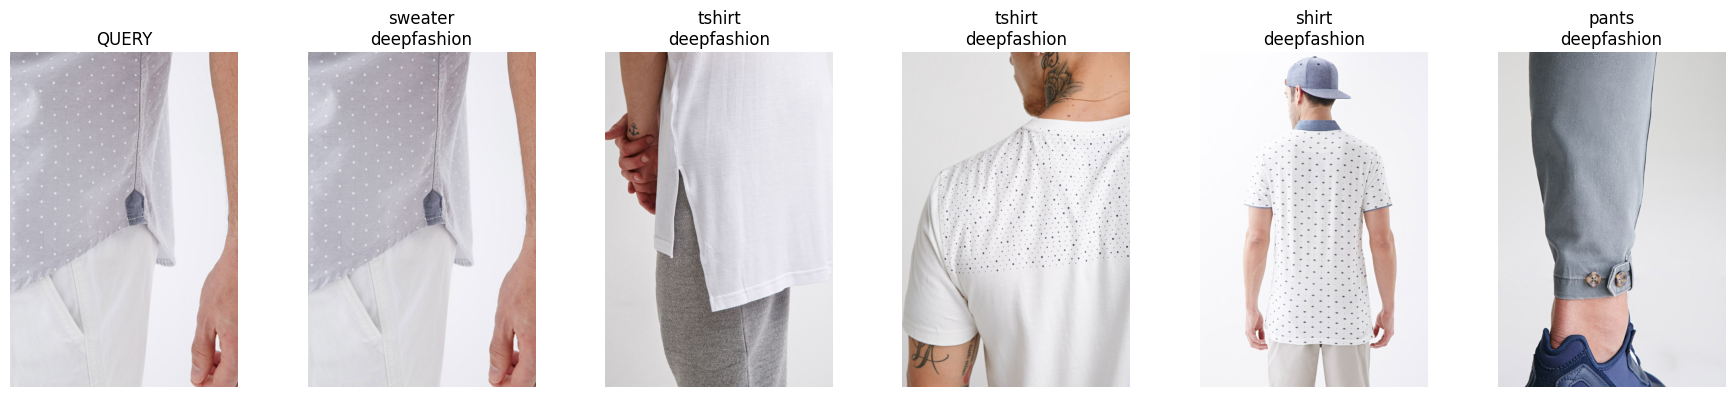

In [40]:
# =========================================================
# VISUALIZE RETRIEVAL RESULTS
# =========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(18, 4))

# =====================================
# QUERY IMAGE
# =====================================

query_image = Image.open(
    query_image_path
).convert("RGB")

plt.subplot(
    1,
    len(results) + 1,
    1
)

plt.imshow(query_image)

plt.title("QUERY")

plt.axis("off")

# =====================================
# RETRIEVED RESULTS
# =====================================

for i, (_, row) in enumerate(results.iterrows()):

    image = Image.open(
        row["image_path"]
    ).convert("RGB")

    plt.subplot(

        1,

        len(results) + 1,

        i + 2
    )

    plt.imshow(image)

    plt.title(

        f"{row['label']}\n"
        f"{row['source']}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [41]:
# =========================================================
# UPLOAD REAL-WORLD QUERY IMAGE
# =========================================================

from google.colab import files

uploaded = files.upload()

Saving Screenshot 2026-05-11 055902.png to Screenshot 2026-05-11 055902.png


In [42]:
# =========================================================
# GET QUERY IMAGE PATH
# =========================================================

query_image_path = list(
    uploaded.keys()
)[0]

print(query_image_path)

Screenshot 2026-05-11 055902.png


In [43]:
# =========================================================
# RUN REAL-WORLD RETRIEVAL
# =========================================================

results = smart_retrieve(

    query_image_path,

    top_k=5,

    min_similarity=0.20
)

print("✅ Retrieval complete.")

results[[
    "gender",
    "label",
    "source",
    "similarity"
]]

✅ Retrieval complete.


,gender,label,source,similarity
50691,MEN,hoodie,deepfashion,0.698507
50223,MEN,hoodie,deepfashion,0.675589
50332,MEN,hoodie,deepfashion,0.668872
50557,MEN,hoodie,deepfashion,0.655712
50650,MEN,hoodie,deepfashion,0.650429


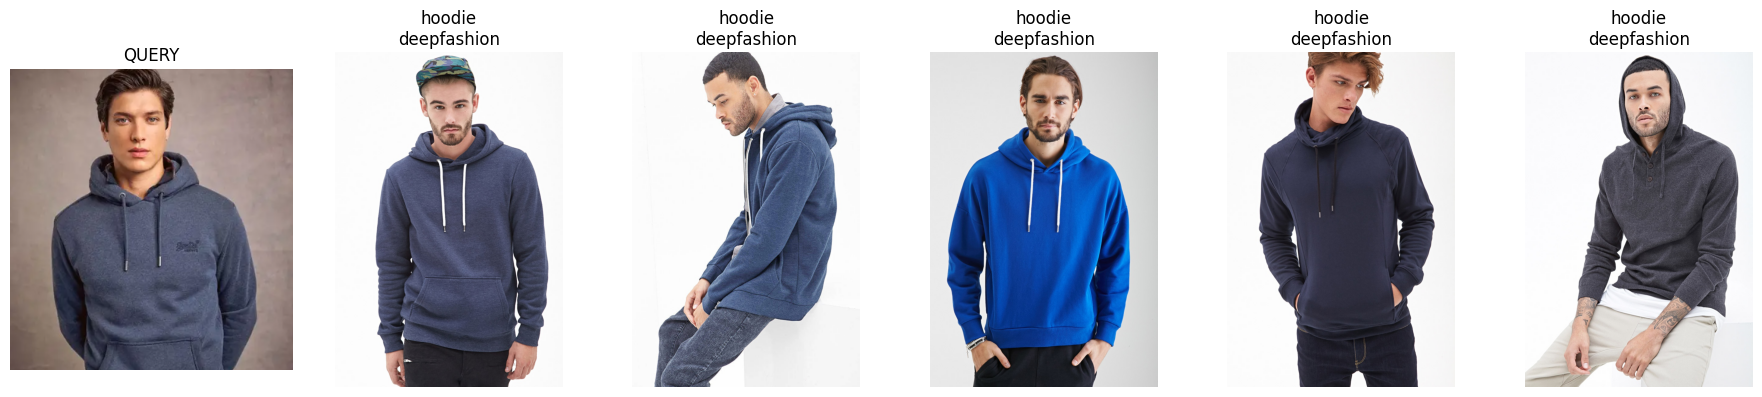

In [44]:
# =========================================================
# VISUALIZE REAL-WORLD RETRIEVAL
# =========================================================

plt.figure(figsize=(18, 4))

# =====================================
# QUERY IMAGE
# =====================================

query_image = Image.open(
    query_image_path
).convert("RGB")

plt.subplot(
    1,
    len(results) + 1,
    1
)

plt.imshow(query_image)

plt.title("QUERY")

plt.axis("off")

# =====================================
# RETRIEVED RESULTS
# =====================================

for i, (_, row) in enumerate(results.iterrows()):

    image = Image.open(
        row["image_path"]
    ).convert("RGB")

    plt.subplot(

        1,

        len(results) + 1,

        i + 2
    )

    plt.imshow(image)

    plt.title(

        f"{row['label']}\n"
        f"{row['source']}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()